# Centros F en haluros alcalinos — Grupo 4

Espectros UV-vis (PerkinElmer Lambda 35, 200–900 nm, paso 1 nm) de cristales de haluros alcalinos irradiados.
Objetivo de esta primera parte: obtener $\lambda_{max}$ de la banda F de cada haluro ajustando una **suma de 2 gaussianas** (+ fondo lineal).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy.optimize import curve_fit

# Importando datos

In [2]:
# La carpeta de datos tiene un nombre largo (con fecha y acentos), la busco por patrón
DATA_DIR = next(Path("data").glob("Scan - Lambda 35*"))

def leer_asc(nombre):
    # Los .asc de UV WinLab tienen 86 líneas de encabezado y usan coma decimal
    df = pd.read_csv(
        DATA_DIR / f"{nombre}.Sample.Raw.asc",
        sep=r"\s+",
        skiprows=86,
        header=None,
        decimal=",",
        engine="python",
    )
    df.columns = ["lambda", "A"]
    return df.sort_values("lambda").reset_index(drop=True)

archivos_G4 = ["G4_NaCl", "G4_ClK", "G4_KBr", "G4_FNa", "G4_FLi", "G4_FLi_2", "G4_FLi_amarillo"]
espectros = {nombre: leer_asc(nombre) for nombre in archivos_G4}
nada = leer_asc("nada vs nada")

espectros["G4_NaCl"].head()

,lambda,A
0,200.0,1.754015
1,201.0,1.746470
2,202.0,1.737095
3,203.0,1.728139
4,204.0,1.723222


# Visualización de los espectros

La medición *nada vs nada* tiene $|A| < 3\times10^{-4}$, así que la línea base del equipo es despreciable frente a las señales de los cristales: no se resta nada.
El fondo que se ve en cada muestra (≈ 0.5–1.5) viene de reflexión/scattering en el cristal y se absorbe con un fondo lineal en el ajuste.
La línea punteada en 326 nm marca el cambio de lámpara (deuterio → halógena).

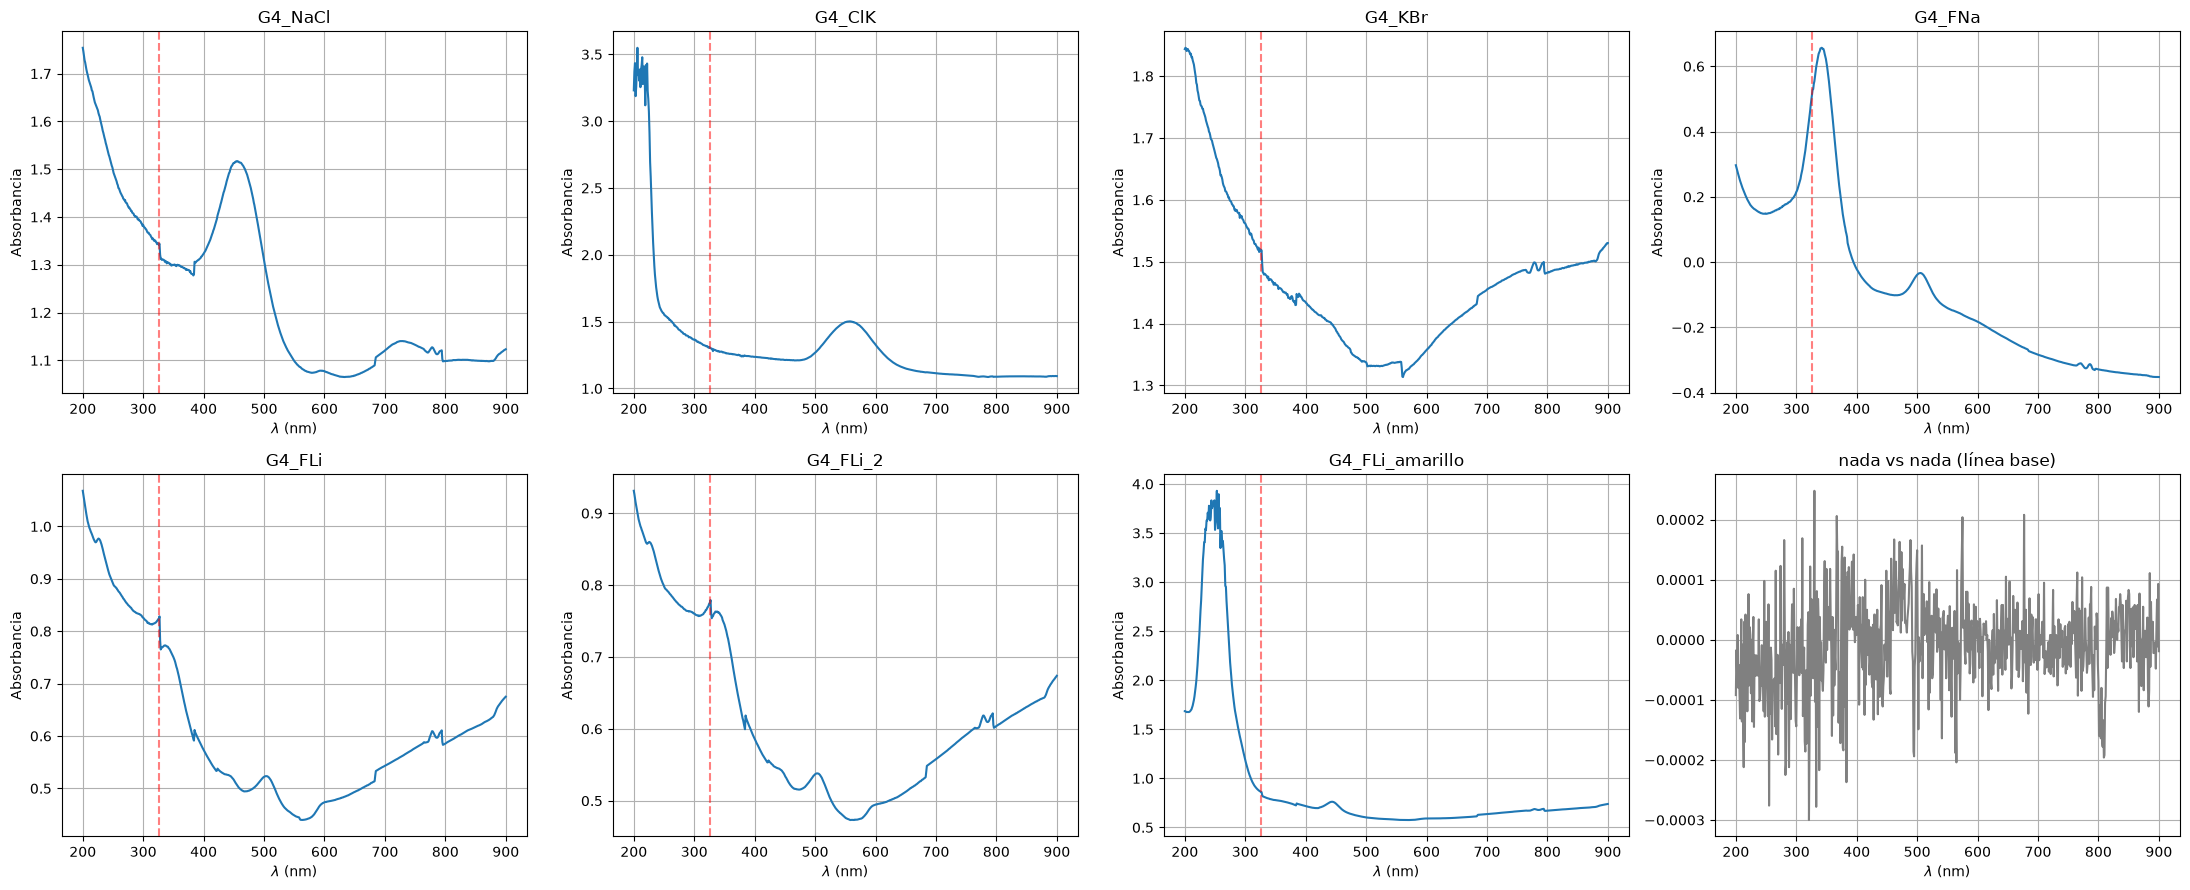

In [3]:
fig, axs = plt.subplots(2, 4, figsize=(22, 9))

for ax, (nombre, df) in zip(axs.flat, espectros.items()):
    ax.plot(df["lambda"], df["A"], label=nombre)
    ax.axvline(326, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel(r"$\lambda$ (nm)")
    ax.set_ylabel("Absorbancia")
    ax.set_title(nombre)
    ax.grid(True)

axs.flat[-1].plot(nada["lambda"], nada["A"], color="gray")
axs.flat[-1].set_title("nada vs nada (línea base)")
axs.flat[-1].set_xlabel(r"$\lambda$ (nm)")
axs.flat[-1].grid(True)

plt.tight_layout()
plt.show()

Observaciones:

- **NaCl**: banda F en ~456 nm y banda M en ~730 nm.
- **KCl**: banda F en ~557 nm, muy limpia.
- **NaF**: banda F en ~342 nm y banda M en ~505 nm.
- **LiF**: sólo `G4_FLi_amarillo` muestra la banda F (~250 nm, en el UV) y la M (~445 nm). `G4_FLi` y `G4_FLi_2` no muestran la banda F, así que para LiF se usa `G4_FLi_amarillo`. El máximo satura (A > 3, se ve ruidoso), por lo que se excluyen del ajuste los puntos con A > 3.
- **KBr**: no se distingue una banda F clara (esperada en ~625 nm). Sólo hay una subida ancha a partir de ~560 nm. Se ajusta igual, pero el resultado es **poco confiable**.
- Hay pequeños saltos instrumentales en ~560, ~690 y ~780 nm (cambios de detector/filtro).

# Ajuste: suma de 2 gaussianas + fondo lineal

$$A(\lambda) = A_1\, e^{-\frac{(\lambda-\lambda_1)^2}{2\sigma_1^2}} + A_2\, e^{-\frac{(\lambda-\lambda_2)^2}{2\sigma_2^2}} + a + b\,(\lambda-500\ \text{nm})$$

La gaussiana 1 es la banda F ($\lambda_{max} = \lambda_1$). La gaussiana 2 es la banda M cuando se ve; en KCl y KBr absorbe el ala/hombro del espectro.
Para cada haluro se elige una ventana de ajuste y valores iniciales a partir de los gráficos anteriores.

In [4]:
def doble_gaussiana(x, amplitud_1, centro_1, sigma_1, amplitud_2, centro_2, sigma_2, fondo, pendiente):
    gaussiana_1 = amplitud_1 * np.exp(-((x - centro_1) ** 2) / (2 * sigma_1**2))
    gaussiana_2 = amplitud_2 * np.exp(-((x - centro_2) ** 2) / (2 * sigma_2**2))
    return gaussiana_1 + gaussiana_2 + fondo + pendiente * (x - 500)

# haluro: (archivo, ventana en nm, parámetros iniciales, A máxima confiable o None)
config_ajuste = {
    "LiF":  ("G4_FLi_amarillo", (205, 600), [3.5, 250, 20, 0.1, 445, 20, 0.7, 0.0], 3.0),
    "NaF":  ("G4_FNa",          (250, 700), [0.6, 342, 25, 0.1, 505, 20, 0.0, -0.001], None),
    "NaCl": ("G4_NaCl",         (400, 880), [0.4, 456, 30, 0.05, 725, 40, 1.1, 0.0], None),
    "KCl":  ("G4_ClK",          (420, 880), [0.3, 557, 35, 0.02, 800, 40, 1.1, 0.0], None),
    "KBr":  ("G4_KBr",          (565, 880), [0.1, 650, 60, 0.01, 780, 20, 1.4, 0.0], None),
}

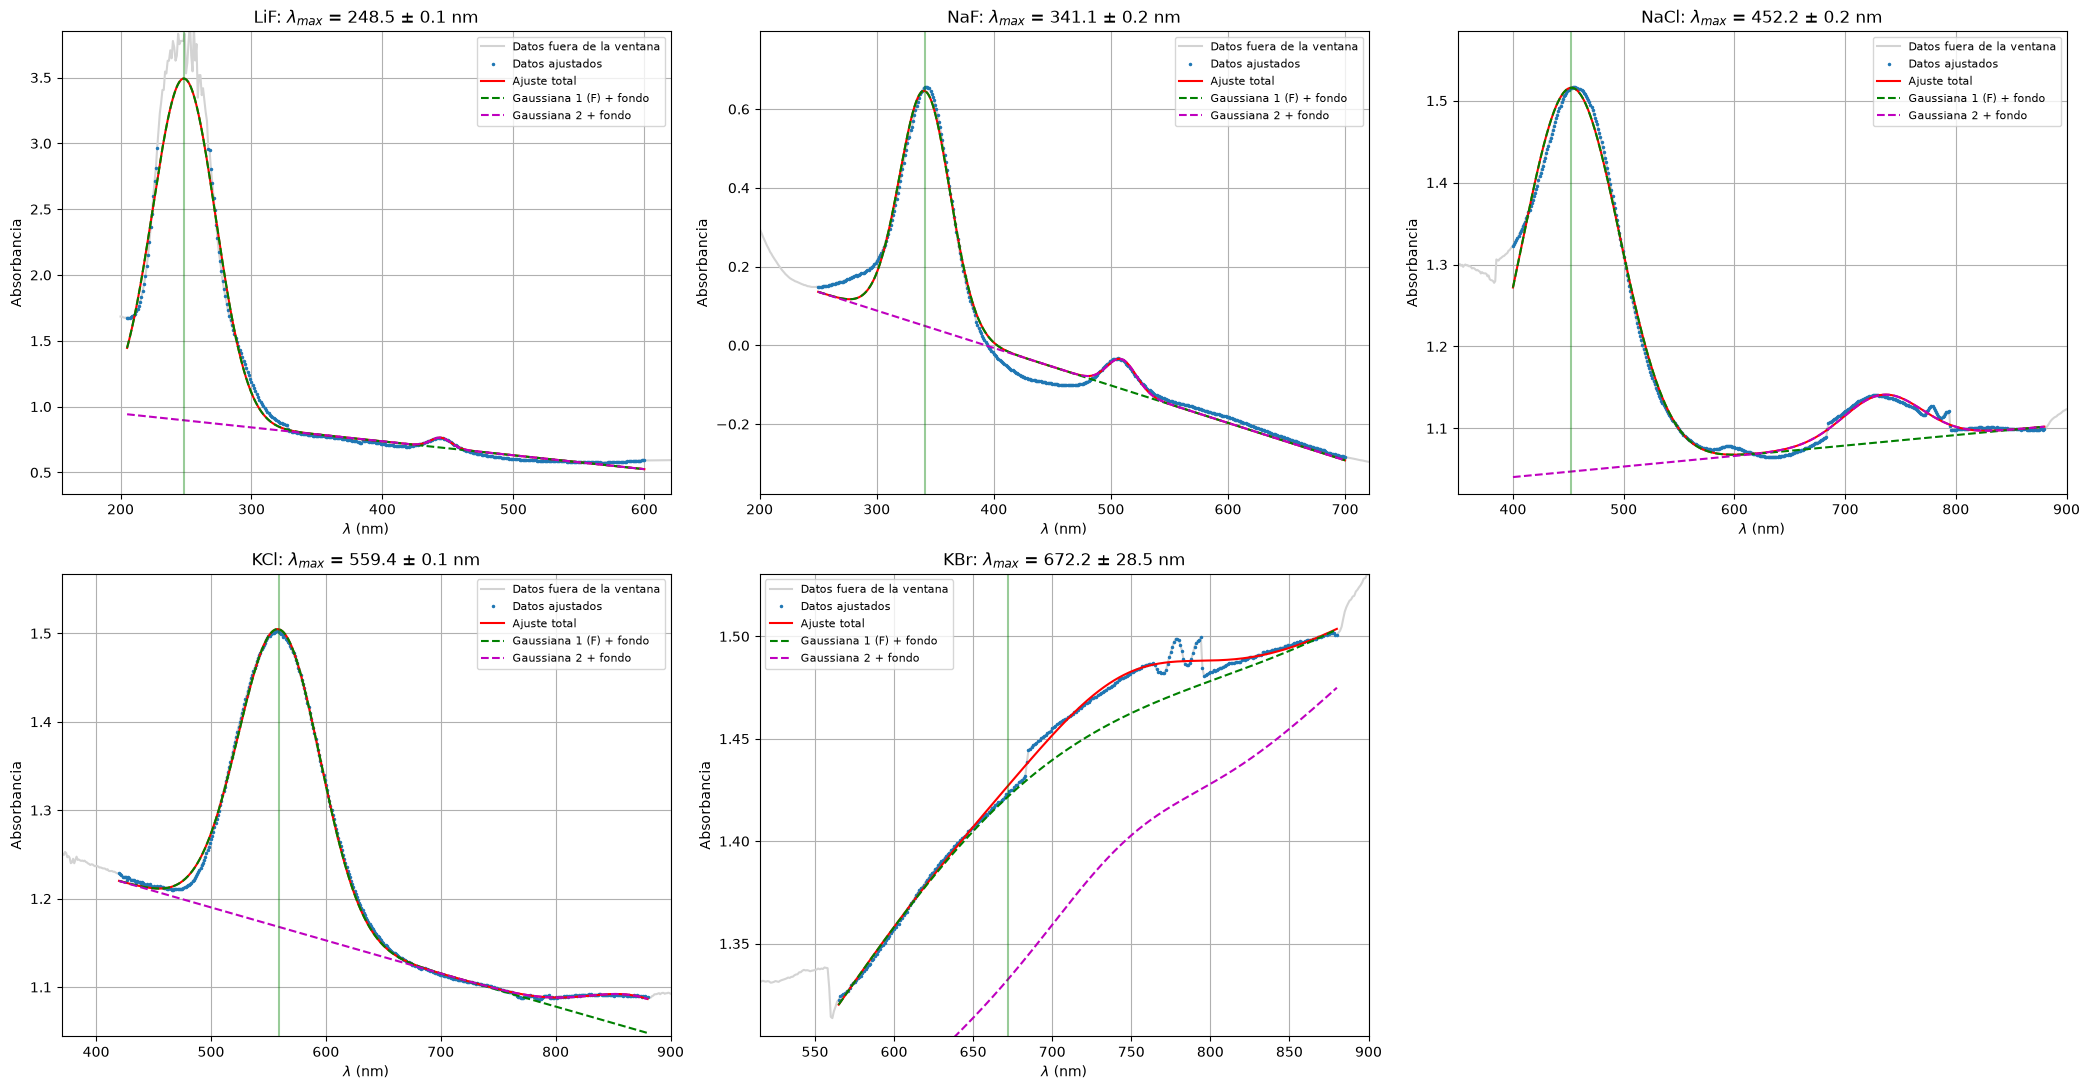

In [5]:
resultados = {}

fig, axs = plt.subplots(2, 3, figsize=(21, 11))

for ax, (haluro, (archivo, (l_min, l_max), p0, A_sat)) in zip(axs.flat, config_ajuste.items()):
    df = espectros[archivo]
    mascara = (df["lambda"] >= l_min) & (df["lambda"] <= l_max)
    if A_sat is not None:
        mascara &= df["A"] < A_sat
    x = df.loc[mascara, "lambda"].to_numpy()
    y = df.loc[mascara, "A"].to_numpy()

    # Centros y anchos acotados a valores razonables
    limites_inf = [0, l_min - 200, 2, 0, l_min - 200, 2, -np.inf, -np.inf]
    limites_sup = [np.inf, l_max + 100, 300, np.inf, l_max + 100, 300, np.inf, np.inf]

    popt, pcov = curve_fit(doble_gaussiana, x, y, p0=p0, bounds=(limites_inf, limites_sup), maxfev=50000)
    perr = np.sqrt(np.diag(pcov))
    residuos = y - doble_gaussiana(x, *popt)
    R2 = 1 - np.sum(residuos**2) / np.sum((y - y.mean()) ** 2)

    resultados[haluro] = {
        "archivo": archivo,
        "lambda_F (nm)": popt[1],
        "err lambda_F (nm)": perr[1],
        "sigma_F (nm)": popt[2],
        "lambda_2 (nm)": popt[4],
        "err lambda_2 (nm)": perr[4],
        "R2": R2,
    }

    x_fino = np.linspace(l_min, l_max, 2000)
    fondo = popt[6] + popt[7] * (x_fino - 500)
    ax.plot(df["lambda"], df["A"], color="lightgray", label="Datos fuera de la ventana")
    ax.plot(x, y, ".", markersize=3, label="Datos ajustados")
    ax.plot(x_fino, doble_gaussiana(x_fino, *popt), "r-", label="Ajuste total")
    ax.plot(x_fino, fondo + popt[0] * np.exp(-((x_fino - popt[1]) ** 2) / (2 * popt[2] ** 2)), "g--", label="Gaussiana 1 (F) + fondo")
    ax.plot(x_fino, fondo + popt[3] * np.exp(-((x_fino - popt[4]) ** 2) / (2 * popt[5] ** 2)), "m--", label="Gaussiana 2 + fondo")
    ax.axvline(popt[1], color="green", alpha=0.4)
    ax.set_xlim(l_min - 50, l_max + 20)
    y_tope = max(y.max(), doble_gaussiana(x_fino, *popt).max())
    ax.set_ylim(y.min() - 0.1 * np.ptp(y), y_tope + 0.15 * np.ptp(y))
    ax.set_xlabel(r"$\lambda$ (nm)")
    ax.set_ylabel("Absorbancia")
    ax.set_title(rf"{haluro}: $\lambda_{{max}}$ = {popt[1]:.1f} ± {perr[1]:.1f} nm")
    ax.legend(fontsize=8)
    ax.grid(True)

axs.flat[-1].axis("off")
plt.tight_layout()
plt.show()

# Resultados: $\lambda_{max}$ de la banda F

Se agrega la energía de transición $E = hc/\lambda_{max}$ y se compara con la tabla de la clase (constantes de celda y energías de transición).

**Ojo con los errores:** el error que da `curve_fit` es sólo estadístico y es muy chico (< 1 nm). La incerteza real está dominada por la elección de la ventana y del modelo de fondo (por ejemplo, en NaCl el máximo de los datos está en 456 nm y el ajuste da ~452 nm por la asimetría de la banda).

In [6]:
hc = 1239.84193  # eV·nm

# Valores de referencia de la clase: energía de transición del centro F (eV)
E_tabla = {"LiF": 5.083, "NaF": 3.702, "NaCl": 2.746, "KCl": 2.295, "KBr": 2.059}

tabla = pd.DataFrame.from_dict(resultados, orient="index")
tabla["E_F (eV)"] = hc / tabla["lambda_F (nm)"]
tabla["err E_F (eV)"] = hc / tabla["lambda_F (nm)"] ** 2 * tabla["err lambda_F (nm)"]
tabla["E tabla (eV)"] = pd.Series(E_tabla)
tabla["lambda tabla (nm)"] = hc / tabla["E tabla (eV)"]
tabla["dif. rel. E (%)"] = 100 * (tabla["E_F (eV)"] - tabla["E tabla (eV)"]) / tabla["E tabla (eV)"]

columnas = ["archivo", "lambda_F (nm)", "err lambda_F (nm)", "lambda tabla (nm)", "E_F (eV)", "err E_F (eV)", "E tabla (eV)", "dif. rel. E (%)", "lambda_2 (nm)", "R2"]
tabla[columnas].round(3)

,archivo,lambda_F (nm),err lambda_F (nm),lambda tabla (nm),E_F (eV),err E_F (eV),E tabla (eV),dif. rel. E (%),lambda_2 (nm),R2
LiF,G4_FLi_amarillo,248.531,0.122,243.919,4.989,0.002,5.083,-1.855,444.620,0.990
NaF,G4_FNa,341.066,0.205,334.911,3.635,0.002,3.702,-1.805,509.164,0.990
NaCl,G4_NaCl,452.212,0.169,451.508,2.742,0.001,2.746,-0.156,733.918,0.996
KCl,G4_ClK,559.367,0.075,540.236,2.217,0.000,2.295,-3.420,876.434,0.999
KBr,G4_KBr,672.207,28.523,602.157,1.844,0.078,2.059,-10.421,746.114,0.997


- LiF, NaF, NaCl y KCl dan $\lambda_{max}$ consistentes con la tabla (diferencias de pocos %).
- KBr: el ajuste da una banda muy ancha y un centro con incerteza enorme; ese espectro no muestra una banda F clara, así que conviene **no usarlo** (o tratarlo aparte) en el análisis de Mollwo-Ivey.

# Ley de Mollwo-Ivey

$\lambda_{max} = C\,a^{n}$ $\;\Rightarrow\;$ $\ln\lambda_{max} = \ln C + n\ln a$. Se usan las constantes de red $a$ de la tabla de la clase y la distancia a primeros vecinos $R_0 = a/2$.
Se ajusta una recta en log-log con y sin KBr (cuyo $\lambda_{max}$ no es confiable).

Convención: acá $n>0$ (λ crece con $a$); la clase lo da como exponente "negativo" porque lo escribe para la energía ($E\propto a^{-n}$).

In [7]:
from scipy.stats import linregress

# Constantes de red (Å) de la tabla de la clase
a_red = pd.Series({"LiF": 4.028, "NaF": 4.634, "NaCl": 5.640, "KCl": 6.294, "KBr": 6.596})
tabla["a (Å)"] = a_red
tabla["R0 = a/2 (Å)"] = a_red / 2

def mollwo_ivey(haluros):
    lna = np.log(tabla.loc[haluros, "a (Å)"].to_numpy(dtype=float))
    lnl = np.log(tabla.loc[haluros, "lambda_F (nm)"].to_numpy(dtype=float))
    return linregress(lna, lnl)

ajustes_MI = {
    "sin KBr": mollwo_ivey(["LiF", "NaF", "NaCl", "KCl"]),
    "con KBr": mollwo_ivey(["LiF", "NaF", "NaCl", "KCl", "KBr"]),
}
for nombre, r in ajustes_MI.items():
    print(f"{nombre}: n = {r.slope:.3f} ± {r.stderr:.3f},  C = {np.exp(r.intercept):.2f} nm/Å^n,  R² = {r.rvalue**2:.4f}")

sin KBr: n = 1.759 ± 0.112,  C = 21.99 nm/Å^n,  R² = 0.9919
con KBr: n = 1.882 ± 0.129,  C = 18.27 nm/Å^n,  R² = 0.9861


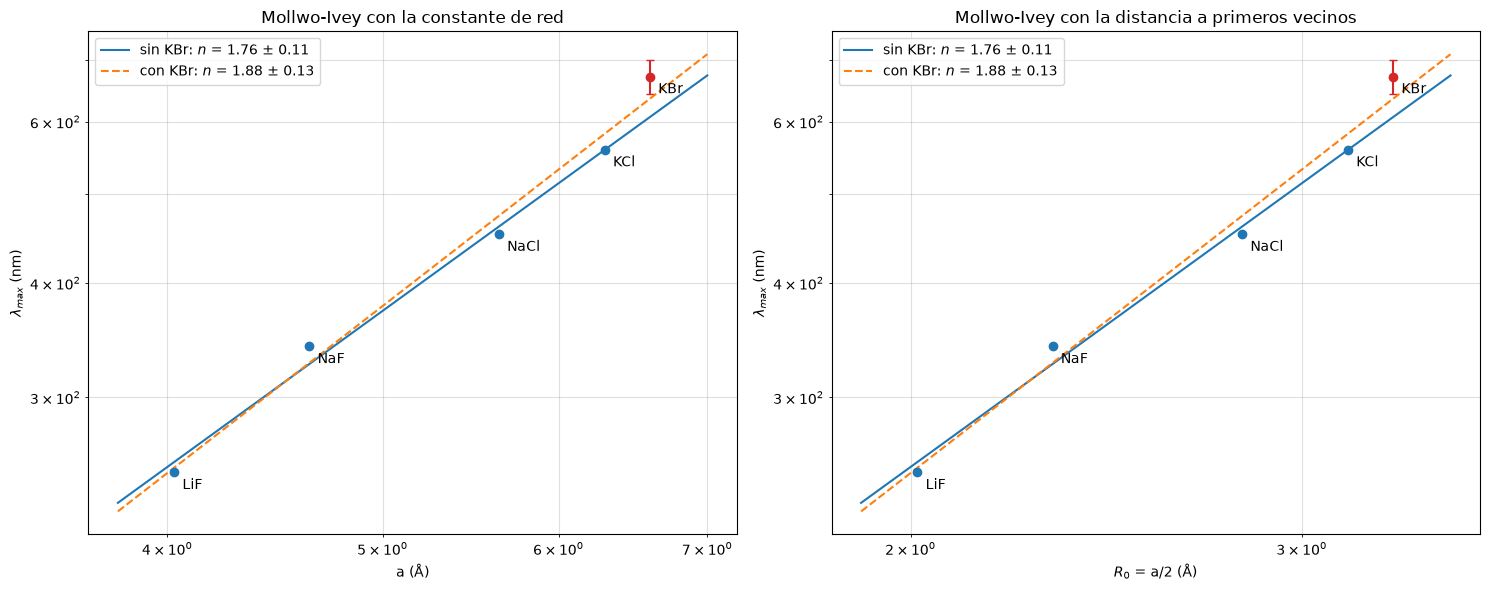

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

a_fino = np.linspace(3.8, 7.0, 200)
for ax, x_col, factor, xlabel in [
    (ax1, "a (Å)", 1.0, "a (Å)"),
    (ax2, "R0 = a/2 (Å)", 0.5, r"$R_0$ = a/2 (Å)"),
]:
    for h in tabla.index:
        ax.errorbar(tabla.loc[h, x_col], tabla.loc[h, "lambda_F (nm)"],
                    yerr=max(tabla.loc[h, "err lambda_F (nm)"], 0.5), fmt="o",
                    color="tab:red" if h == "KBr" else "tab:blue", capsize=3)
        ax.annotate(h, (tabla.loc[h, x_col], tabla.loc[h, "lambda_F (nm)"]),
                    textcoords="offset points", xytext=(6, -12))
    for (nombre, r), estilo in zip(ajustes_MI.items(), ["-", "--"]):
        ax.plot(a_fino * factor, np.exp(r.intercept) * a_fino**r.slope, estilo,
                label=rf"{nombre}: $n$ = {r.slope:.2f} ± {r.stderr:.2f}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel(r"$\lambda_{max}$ (nm)")
    ax.legend(); ax.grid(True, which="both", alpha=0.4)

ax1.set_title("Mollwo-Ivey con la constante de red")
ax2.set_title("Mollwo-Ivey con la distancia a primeros vecinos")
plt.tight_layout()
plt.show()

# Comparación con los pozos infinitos

- **Pozo cúbico** de arista $a$: $\Delta E = \dfrac{3h^2}{8ma^2}$
- **Pozo esférico** de radio $r = a/2$: $\Delta E = 10.315\,\dfrac{\hbar^2}{2mr^2}$

Ambos dan $E\propto a^{-2}$, o sea $n=2$. Se calcula $\Delta E$ con $\hbar^2/2m = 3.80998$ eV·Å² y se compara con la energía medida.

In [9]:
hb2_2m = 3.80998  # ħ²/(2m_e) en eV·Å²

tabla["E cúbico (eV)"] = 3 * np.pi**2 * hb2_2m / tabla["a (Å)"] ** 2           # 3h²/(8ma²) = 3π²·ħ²/(2m a²)
tabla["E esférico r=a/2 (eV)"] = 10.315 * hb2_2m / tabla["R0 = a/2 (Å)"] ** 2

comparacion = tabla[["a (Å)", "E_F (eV)", "E cúbico (eV)", "E esférico r=a/2 (eV)"]].copy()
comparacion["E_F / E cúbico"] = comparacion["E_F (eV)"] / comparacion["E cúbico (eV)"]
comparacion["E_F / E esférico"] = comparacion["E_F (eV)"] / comparacion["E esférico r=a/2 (eV)"]
print(comparacion.astype(float).round(3).to_string())

# Ajuste de E_F vs a en log-log: pendiente esperada -2
r_E = linregress(np.log(a_red[["LiF", "NaF", "NaCl", "KCl"]]), np.log(tabla.loc[["LiF", "NaF", "NaCl", "KCl"], "E_F (eV)"].astype(float)))
print(f"\nE_F ∝ a^m (sin KBr): m = {r_E.slope:.3f} ± {r_E.stderr:.3f}")

      a (Å)  E_F (eV)  E cúbico (eV)  E esférico r=a/2 (eV)  E_F / E cúbico  E_F / E esférico
LiF   4.028     4.989          6.953                  9.689           0.717             0.515
NaF   4.634     3.635          5.253                  7.320           0.692             0.497
NaCl  5.640     2.742          3.546                  4.942           0.773             0.555
KCl   6.294     2.217          2.848                  3.968           0.778             0.559
KBr   6.596     1.844          2.593                  3.613           0.711             0.510

E_F ∝ a^m (sin KBr): m = -1.759 ± 0.112


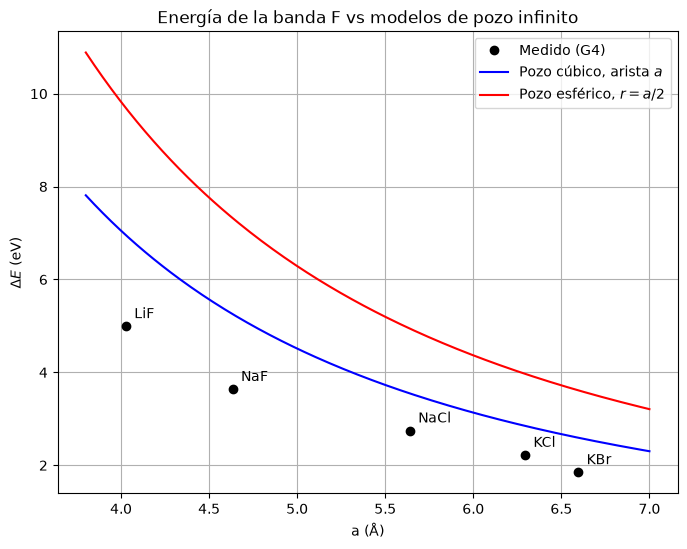

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(tabla["a (Å)"], tabla["E_F (eV)"].astype(float), "ko", label="Medido (G4)")
ax.plot(a_fino, 3 * np.pi**2 * hb2_2m / a_fino**2, "b-", label="Pozo cúbico, arista $a$")
ax.plot(a_fino, 10.315 * hb2_2m / (a_fino / 2) ** 2, "r-", label="Pozo esférico, $r=a/2$")
for h in tabla.index:
    ax.annotate(h, (tabla.loc[h, "a (Å)"], tabla.loc[h, "E_F (eV)"]), textcoords="offset points", xytext=(6, 6))
ax.set_xlabel("a (Å)"); ax.set_ylabel(r"$\Delta E$ (eV)")
ax.set_title("Energía de la banda F vs modelos de pozo infinito")
ax.legend(); ax.grid(True)
plt.show()

Los pozos infinitos reproducen la tendencia ($n\approx2$; el ajuste da $n\approx1.8$–$1.9$) pero no el valor absoluto: el cúbico sobreestima $\Delta E$ en un factor $\sim$1.3–1.4 y el esférico con $r=a/2$ en $\sim$1.8–2. El pozo real es **finito** (profundidad $\sim eV_{Mad}$), y eso baja la energía de transición. Es el próximo punto del procedimiento.

# Pozo esférico finito

Ahora el pozo tiene profundidad finita $V_0$ y radio $r_0 = a/2$ (la vacante aniónica). Medimos la energía $E$ desde el borde superior del pozo, así que los estados ligados tienen $E<0$.

Dentro del pozo ($r<r_0$) la solución radial es una Bessel esférica $j_l(kr)$ y afuera una decreciente $k_l(\kappa r)$:

$$k=\frac{\sqrt{2m\,(E+V_0)}}{\hbar},\qquad \kappa=\frac{\sqrt{-2mE}}{\hbar}$$

Pedir que $R(r)$ y su derivada sean continuas en $r_0$ (igualar la derivada logarítmica) da la condición de cuantización. Con $\xi = k r_0$ y $\eta = \kappa r_0$:

$$\xi\, j_l'(\xi)\,k_l(\eta) - \eta\, k_l'(\eta)\, j_l(\xi) = 0,\qquad \xi^2+\eta^2 = z_0^2 = \frac{V_0\, r_0^2}{\hbar^2/2m}$$

- $l=0$ ($1s$, estado fundamental): existe un estado ligado si $z_0 > \pi/2$.
- $l=1$ ($1p$, primer excitado): sólo está ligado si $z_0 > \pi$. **Esto es importante:** si el pozo es poco profundo, el $1p$ ya está en el continuo y la "absorción" lleva al electrón hacia fuera de la vacante.

Cuando $V_0\to\infty$ se recupera $\xi_{1,0}=\pi$ y $\xi_{1,1}=4.493$ (tabla de ceros de Bessel de la clase).

In [11]:
from scipy.special import spherical_jn, spherical_kn
from scipy.optimize import brentq

hb2_2m = 3.80998   # ħ²/(2 m_e) en eV·Å²
e2_4pieps0 = 14.3996  # e²/(4π ε0) en eV·Å
M_madelung = 1.7476   # constante de Madelung, estructura NaCl

def condicion(xi, l, z0):
    # Continuidad de la derivada logarítmica en r0 (forma sin polos). Vectorizada en xi.
    eta = np.sqrt(np.clip(z0**2 - xi**2, 0, None))
    return (xi * spherical_jn(l, xi, derivative=True) * spherical_kn(l, eta)
            - eta * spherical_kn(l, eta, derivative=True) * spherical_jn(l, xi))

def xi_ligado(l, z0):
    # Primera raíz de la condición en (0, z0): primer estado ligado con ese l. NaN si no existe.
    xs = np.linspace(1e-4, z0 - 1e-6, 2000)
    v = condicion(xs, l, z0)
    cambios = np.where(v[:-1] * v[1:] < 0)[0]
    if len(cambios) == 0:
        return np.nan
    i = cambios[0]
    return brentq(condicion, xs[i], xs[i + 1], args=(l, z0))

def niveles(V0, r0):
    # Energías (eV, medidas desde el borde del pozo) de 1s y 1p, y energía cinética del 1s desde el fondo.
    z0 = r0 * np.sqrt(V0 / hb2_2m)
    xi_s, xi_p = xi_ligado(0, z0), xi_ligado(1, z0)
    E_s = hb2_2m * xi_s**2 / r0**2 - V0
    E_p = hb2_2m * xi_p**2 / r0**2 - V0
    return E_s, E_p, hb2_2m * xi_s**2 / r0**2

# Chequeo: al crecer z0 las raíces tienden a los ceros de Bessel (π para 1s, 4.4934 para 1p)
for z0 in [5, 10, 20, 30]:
    print(f"z0 = {z0:>2}:  xi(1s) = {xi_ligado(0, z0):.3f},  xi(1p) = {xi_ligado(1, z0):.3f}")
print(f"pozo infinito: xi(1s) = {np.pi:.3f},  xi(1p) = 4.493")

z0 =  5:  xi(1s) = 2.596,  xi(1p) = 3.679
z0 = 10:  xi(1s) = 2.852,  xi(1p) = 4.075
z0 = 20:  xi(1s) = 2.991,  xi(1p) = 4.278
z0 = 30:  xi(1s) = 3.040,  xi(1p) = 4.348
pozo infinito: xi(1s) = 3.142,  xi(1p) = 4.493


## Gráfico de los niveles para NaCl

Tomo NaCl ($r_0 = 2.82$ Å) y muestro cómo cambian $E_{1s}$, $E_{1p}$ y la diferencia $\Delta E$ al variar la profundidad $V_0$. La línea horizontal es la energía medida de la banda F. El $1p$ aparece recién para $V_0 > \hbar^2\pi^2/(2m r_0^2)$.

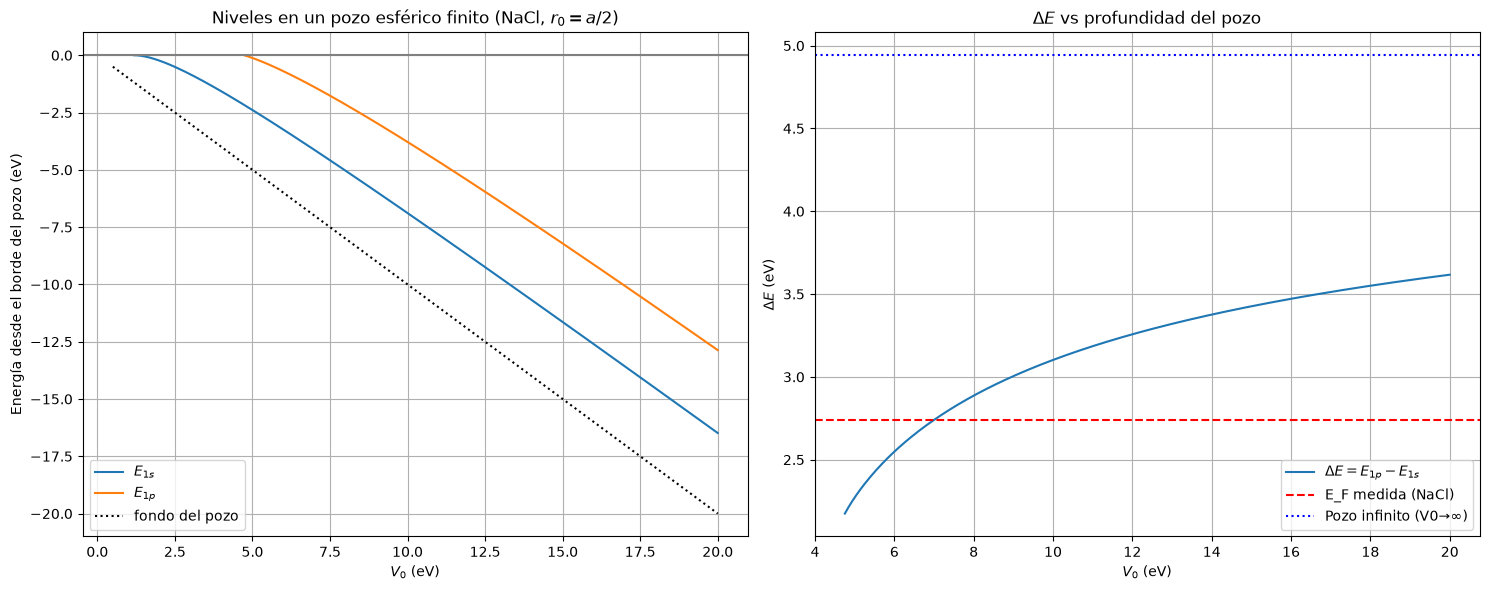

In [12]:
r0_NaCl = a_red["NaCl"] / 2
V0_barrido = np.linspace(0.5, 20, 400)
res = np.array([niveles(V, r0_NaCl) for V in V0_barrido])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(V0_barrido, res[:, 0], label=r"$E_{1s}$")
ax1.plot(V0_barrido, res[:, 1], label=r"$E_{1p}$")
ax1.plot(V0_barrido, -V0_barrido, "k:", label="fondo del pozo")
ax1.axhline(0, color="gray")
ax1.set_xlabel(r"$V_0$ (eV)"); ax1.set_ylabel("Energía desde el borde del pozo (eV)")
ax1.set_title(r"Niveles en un pozo esférico finito (NaCl, $r_0=a/2$)")
ax1.legend(); ax1.grid(True)

ax2.plot(V0_barrido, res[:, 1] - res[:, 0], label=r"$\Delta E = E_{1p}-E_{1s}$")
ax2.axhline(tabla.loc["NaCl", "E_F (eV)"], color="r", linestyle="--", label="E_F medida (NaCl)")
ax2.axhline(10.315 * hb2_2m / r0_NaCl**2, color="b", linestyle=":", label="Pozo infinito (V0→∞)")
ax2.set_xlabel(r"$V_0$ (eV)"); ax2.set_ylabel(r"$\Delta E$ (eV)")
ax2.set_title(r"$\Delta E$ vs profundidad del pozo")
ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

# Ajuste de la profundidad del pozo

Para cada haluro fijo $r_0 = a/2$ y busco el $V_0$ para el cual $\Delta E = E_{1p}-E_{1s}$ coincide con la energía medida de la banda F, $E_F=hc/\lambda_{max}$. Es una ecuación en una sola incógnita, se resuelve con `brentq`.
(Hay que recorrer $V_0$ empezando por el umbral donde existe el $1p$.)

In [13]:
def delta_E(V0, r0):
    E_s, E_p, _ = niveles(V0, r0)
    return E_p - E_s

def ajustar_V0(E_medida, r0):
    V_umbral = hb2_2m * np.pi**2 / r0**2          # z0 = π: aparece el 1p
    V_grilla = np.linspace(V_umbral * 1.001, 80, 300)
    dE = np.array([delta_E(V, r0) for V in V_grilla]) - E_medida
    cambios = np.where(dE[:-1] * dE[1:] < 0)[0]
    if len(cambios) == 0:
        return np.nan
    i = cambios[0]
    return brentq(lambda V: delta_E(V, r0) - E_medida, V_grilla[i], V_grilla[i + 1])

tabla["V0 ajustado (eV)"] = [ajustar_V0(tabla.loc[h, "E_F (eV)"], tabla.loc[h, "R0 = a/2 (Å)"]) for h in tabla.index]
tabla["V0 ajustado (eV)"]

LiF     11.727309
NaF      8.305100
NaCl     7.009054
KCl      5.720178
KBr      4.303621
Name: V0 ajustado (eV), dtype: float64

# Potencial de Madelung y estimación del gap

El potencial electrostático que siente un electrón en el sitio de la vacante aniónica es

$$V_{Mad} = \frac{e}{4\pi\varepsilon_0}\,\frac{M}{a},\qquad M\simeq 1.7476\ \text{(red tipo NaCl)}$$

y, como indica la clase, la profundidad del pozo es $eV_{Mad}$. Con eso se estima todo **sin parámetros libres**:

1. $\Delta E = E_{1p}-E_{1s}$ con $V_0 = eV_{Mad}$ y $r_0=a/2$ (el *gap* de absorción estimado).
2. Energía de ionización del centro F: $E_i \approx eV_{Mad} - E_0$, con $E_0$ la energía del $1s$ medida desde el fondo del pozo.

Si el $1p$ no está ligado con $V_0=eV_{Mad}$, el modelo no da un $\Delta E$ discreto (aparece como `NaN`). Es una limitación real del modelo con $r_0=a/2$, no un error del código.

In [14]:
tabla["eV_Mad (eV)"] = e2_4pieps0 * M_madelung / tabla["a (Å)"]

filas = {}
for h in tabla.index:
    r0 = tabla.loc[h, "R0 = a/2 (Å)"]
    V_mad = tabla.loc[h, "eV_Mad (eV)"]
    E_s, E_p, E0_fondo = niveles(V_mad, r0)
    filas[h] = {
        "z0 = r0*sqrt(V/(ħ²/2m))": r0 * np.sqrt(V_mad / hb2_2m),
        "eV_Mad (eV)": V_mad,
        "E_1s (eV, desde el borde)": E_s,
        "E_1p (eV, desde el borde)": E_p,
        "ΔE Madelung (eV)": E_p - E_s,
        "E_F medida (eV)": tabla.loc[h, "E_F (eV)"],
        "V0 ajustado (eV)": tabla.loc[h, "V0 ajustado (eV)"],
        "V0 ajustado / eV_Mad": tabla.loc[h, "V0 ajustado (eV)"] / V_mad,
        "E_i = eV_Mad - E0 (eV)": V_mad - E0_fondo,
    }
madelung = pd.DataFrame.from_dict(filas, orient="index")
madelung.round(3)

,z0 = r0*sqrt(V/(ħ²/2m)),eV_Mad (eV),"E_1s (eV, desde el borde)","E_1p (eV, desde el borde)",ΔE Madelung (eV),E_F medida (eV),V0 ajustado (eV),V0 ajustado / eV_Mad,E_i = eV_Mad - E0 (eV)
LiF,2.579,6.247,-1.892,NaN,NaN,4.989,11.727,1.877,1.892
NaF,2.766,5.430,-1.952,NaN,NaN,3.635,8.305,1.529,1.952
NaCl,3.052,4.462,-1.945,NaN,NaN,2.742,7.009,1.571,1.945
KCl,3.224,3.998,-1.905,-0.087,1.818,2.217,5.720,1.431,1.905
KBr,3.300,3.815,-1.882,-0.168,1.714,1.844,4.304,1.128,1.882


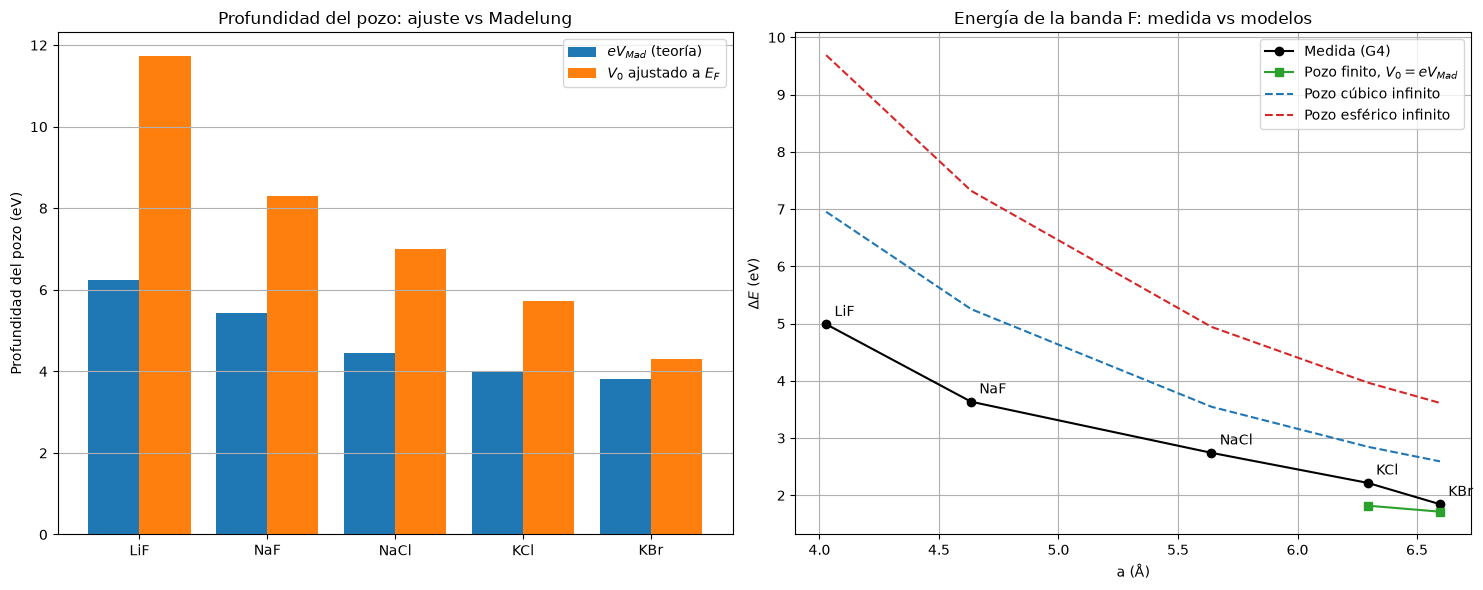

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# (a) Profundidad ajustada vs Madelung
x = np.arange(len(tabla))
ax1.bar(x - 0.2, tabla["eV_Mad (eV)"], 0.4, label=r"$eV_{Mad}$ (teoría)")
ax1.bar(x + 0.2, tabla["V0 ajustado (eV)"], 0.4, label=r"$V_0$ ajustado a $E_F$")
ax1.set_xticks(x); ax1.set_xticklabels(tabla.index)
ax1.set_ylabel("Profundidad del pozo (eV)")
ax1.set_title("Profundidad del pozo: ajuste vs Madelung")
ax1.legend(); ax1.grid(True, axis="y")

# (b) Energía de absorción: modelos vs medida
ax2.plot(tabla["a (Å)"], tabla["E_F (eV)"], "ko-", label="Medida (G4)")
ax2.plot(tabla["a (Å)"], madelung["ΔE Madelung (eV)"], "s-", color="tab:green", label=r"Pozo finito, $V_0=eV_{Mad}$")
ax2.plot(tabla["a (Å)"], tabla["E cúbico (eV)"], "--", color="tab:blue", label="Pozo cúbico infinito")
ax2.plot(tabla["a (Å)"], tabla["E esférico r=a/2 (eV)"], "--", color="tab:red", label="Pozo esférico infinito")
for h in tabla.index:
    ax2.annotate(h, (tabla.loc[h, "a (Å)"], tabla.loc[h, "E_F (eV)"]), textcoords="offset points", xytext=(6, 6))
ax2.set_xlabel("a (Å)"); ax2.set_ylabel(r"$\Delta E$ (eV)")
ax2.set_title("Energía de la banda F: medida vs modelos")
ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

## Interpretación

- Con el pozo **finito** la energía de transición baja respecto de los pozos infinitos (ver gráfico de niveles): $\Delta E$ crece con $V_0$ y tiende al valor del pozo infinito.
- Con $V_0=eV_{Mad}$ y $r_0=a/2$ el $1p$ está ligado sólo en KCl y KBr ($z_0>\pi$). En LiF, NaF y NaCl no hay $1p$ ligado: el modelo no da un $\Delta E$ discreto. Para KCl da $\approx 1.8$ eV contra $2.2$ eV medidos.
- La profundidad $V_0$ que **hace falta** para reproducir $E_F$ es siempre **mayor** que $eV_{Mad}$ (relación $V_0/eV_{Mad}\approx 1.1$–$1.9$ en la tabla), y la discrepancia crece para los cristales de iones chicos (LiF, NaF). Es decir, el potencial de Madelung de un ion puntual subestima la profundidad efectiva: el pozo real es más profundo/angosto que el cuadrado de radio $a/2$ (polarización de los iones vecinos, penetración del electrón en los carozos, etc.).
- Por construcción $E_i = eV_{Mad}-E_0 = -E_{1s}$ (el $E_0$ medido desde el fondo). Con $V_0=eV_{Mad}$ da $\approx 1.9$ eV casi igual en todos los haluros, mientras que $E_F$ varía entre 1.8 y 5 eV: la energía de ionización calculada así es mucho menos sensible a $a$ que la transición medida.
- KBr: el $\lambda_{max}$ no es confiable, así que su fila no debe usarse para sacar conclusiones.

# Posibles correcciones al modelo (propuestas, **no implementadas todavía**)

Resumen del problema: con $V_0 = eV_{Mad}$ ($=e^2M/4\pi\varepsilon_0 a$) y $r_0=a/2$ el $1p$ no está ligado en LiF, NaF y NaCl, y el pozo que sí reproduce $E_F$ es entre 1.1 y 1.9 veces más profundo. Antes de elegir una corrección conviene saber **qué puede arreglar el problema y qué no**. Las dos celdas siguientes lo muestran.

In [16]:
# (1) Cota del pozo esférico cuadrado: ΔE/V0 depende sólo de z0 = r0*sqrt(V0/(ħ²/2m)).
#     Con r0 = 1 Å, V0 = (ħ²/2m)·z0² => ΔE/V0 = f(z0). Busco su máximo para z0 > π (1p ligado).
zs = np.linspace(np.pi * 1.0005, 12, 60)
razon = np.array([delta_E(hb2_2m * z**2, 1.0) / (hb2_2m * z**2) for z in zs])
print(f"max(ΔE/V0) = {razon.max():.3f}  (en z0 = {zs[razon.argmax()]:.3f}, o sea justo en el umbral z0 = π)")

# Consecuencia: ΔE = E_F exige V0 >= E_F / 0.458 sea cual sea r0 (o la masa efectiva m*, que sólo reescala z0).
cota = pd.DataFrame({
    "E_F (eV)": tabla["E_F (eV)"],
    "V0 mínimo = E_F/0.458 (eV)": tabla["E_F (eV)"] / razon.max(),
    "eV_Mad con a (eV)": tabla["eV_Mad (eV)"],
    "eV_Mad con R0=a/2 (eV)": e2_4pieps0 * M_madelung / tabla["R0 = a/2 (Å)"],
})
cota.round(2)

max(ΔE/V0) = 0.458  (en z0 = 3.143, o sea justo en el umbral z0 = π)


,E_F (eV),V0 mínimo = E_F/0.458 (eV),eV_Mad con a (eV),eV_Mad con R0=a/2 (eV)
LiF,4.99,10.90,6.25,12.49
NaF,3.64,7.94,5.43,10.86
NaCl,2.74,5.99,4.46,8.92
KCl,2.22,4.84,4.00,8.00
KBr,1.84,4.03,3.82,7.63


In [17]:
# (2) Madelung referido a la distancia a primeros vecinos R0 = a/2 (convención de Kittel: U = -N α q²/R0)
filas = {}
for h in tabla.index:
    R0 = tabla.loc[h, "R0 = a/2 (Å)"]
    V = e2_4pieps0 * M_madelung / R0
    filas[h] = {"V_Mad(R0) (eV)": V, "z0": R0 * np.sqrt(V / hb2_2m), "ΔE (eV)": delta_E(V, R0),
                "E_F medida (eV)": tabla.loc[h, "E_F (eV)"]}
madelung_R0 = pd.DataFrame.from_dict(filas, orient="index")
madelung_R0["dif. rel. (%)"] = 100 * (madelung_R0["ΔE (eV)"] - madelung_R0["E_F medida (eV)"]) / madelung_R0["E_F medida (eV)"]
madelung_R0.round(3)

,V_Mad(R0) (eV),z0,ΔE (eV),E_F medida (eV),dif. rel. (%)
LiF,12.495,3.647,5.150,4.989,3.242
NaF,10.861,3.912,4.137,3.635,13.805
NaCl,8.924,4.316,2.996,2.742,9.286
KCl,7.996,4.559,2.488,2.217,12.251
KBr,7.630,4.667,2.296,1.844,24.473


## Lectura de los dos resultados anteriores

1. **Cota universal.** En un pozo esférico cuadrado $\Delta E/V_0$ depende sólo de $z_0$ y alcanza su máximo ($\approx 0.458$) justo cuando el $1p$ se desliga. Entonces $E_F \lesssim 0.46\,V_0$ para **cualquier** $r_0$ y cualquier masa efectiva $m^*$ (ambos sólo mueven $z_0$). Con $eV_{Mad}$ referido a $a$ esa condición no se cumple en ningún haluro (comparar columnas de la tabla). **Conclusión: dejar $r_0$ libre no alcanza por sí solo**; hay que cambiar también la profundidad o la forma del potencial.
2. **Convención de Madelung.** La constante $M=1.7476$ (Kittel, Madelung de la clase) está definida respecto de la distancia entre vecinos más próximos $R_0=a/2$: $V_{Mad}=\dfrac{e}{4\pi\varepsilon_0}\dfrac{M}{R_0}$. En la diapositiva se escribe con $a$, que duplica el denominador. Con $R_0$ el pozo es el doble de profundo y, **sin parámetros libres**, el modelo ya da $\Delta E$ dentro de ~3 % (LiF) a ~25 % (KBr) del valor medido, y el $1p$ queda ligado en todos los haluros.

## Opciones, ordenadas por simplicidad

**A. Usar $V_{Mad}$ con $R_0=a/2$ (corrección de convención).** Cero parámetros libres. Es la primera que conviene probar; el resultado de arriba sugiere que es físicamente la correcta. Después hay que revisar el sesgo sistemático (el modelo sobreestima $E_F$ entre 3 % y 25 %).

**B. Radio $r_0$ libre (global).** $r_0=\alpha\, a/2$ con un único $\alpha$ para todos los haluros, ajustado por mínimos cuadrados sobre LiF, NaF, NaCl, KCl (KBr aparte). Es físicamente razonable que $r_0$ no sea exactamente $a/2$: la vacante ocupa el lugar del anión y el electrón se extiende hasta los cationes vecinos. Criterios alternativos de la clase para fijar $r_0$ (sin ajustar): radio iónico del anión ($\mathrm{Cl^-}\approx1.67$ Å), esfera de igual volumen que el octaedro ($r_0\approx0.34\,a$), $r_0=a/2$. Por la cota anterior, **sólo tiene sentido combinarlo con A** (profundidad de Madelung con $R_0$).

**C. Profundidad escalada $V_0=\beta\, eV_{Mad}$ (global).** Un $\beta$ común que absorba lo que el pozo cuadrado no captura (penetración del electrón en los carozos iónicos, forma real del potencial). Se puede ajustar junto con $\alpha$ de B (2 parámetros para 4 haluros); ojo con la degeneración entre $\alpha$ y $\beta$ y con reportar incertezas del ajuste.

**D. Masa efectiva $m^*\ne m_e$.** Cambia $\hbar^2/2m \to \hbar^2/2m^*$. Es un parámetro global más, físicamente motivado (electrón en la banda de conducción del cristal, $m^*\sim0.5$–$1\,m_e$ en haluros alcalinos). Como muestra la cota, sólo reescala $z_0$ y es **casi degenerado con $r_0$** ($z_0^2\propto m^* V_0 r_0^2$), así que no conviene ajustar $r_0$ y $m^*$ a la vez con tan pocos datos.

**E. Apantallamiento dieléctrico.** El electrón polariza la red, de modo que el potencial efectivo se reduce por $\varepsilon_\infty$ (rápido, electrónico) o $\varepsilon_0$ (lento). Ojo: esto **vuelve el pozo más chico**, o sea que empuja en el sentido equivocado respecto del problema actual; sólo se justifica si se agregan al mismo tiempo la cola coulombiana fuera de la vacante (modelo de Simpson) o la relajación de la red.

**F. Forma del potencial más realista.** (i) Pozo cuadrado de radio $r_0$ más una cola coulombiana apantallada $-e^2/(4\pi\varepsilon_0\varepsilon\, r)$ para $r>r_0$. (ii) Pozo con simetría octaédrica en lugar de esférico: el electrón ve 6 cationes a distancia $R_0$; una aproximación manejable es un potencial separable $V=V_x+V_y+V_z$ de tres pozos 1D finitos de ancho $a$ (el cúbico finito exacto no es separable por las esquinas).

**G. Estado excitado en el continuo.** El $1p$ puede estar cuasi-ligado o en el continuo, así que la banda F es una transición ligado→resonancia. En vez de $E_{1p}-E_{1s}$ se puede calcular la fuerza del oscilador $|\langle 1s|\,\mathbf{r}\,|E,l{=}1\rangle|^2$ y ubicar el pico de absorción. Es lo más exigente de las siete.

**H. Relajación de red / Franck–Condon.** La absorción es vertical (red congelada), pero el estado fundamental ya tiene los cationes vecinos desplazados respecto de la red ideal ($r_0$ efectivo distinto). Además el ancho de la banda ($\sigma_F$ del ajuste gaussiano) contiene información del acople electrón–fonón (factor de Huang–Rhys, $\sigma^2\propto\coth(\hbar\omega/2k_BT)$). Los $\sigma_F$ ya están en la tabla de resultados; comparar su tendencia con $a$ da un chequeo independiente del modelo.

## Recomendación de orden

1. Probar **A** (sin parámetros libres) y mirar los residuos por haluro.
2. Si hay un sesgo sistemático, agregar **B** ($\alpha$ global) y/o **D** ($m^*$), de a **un** parámetro por vez.
3. Dejar **F–H** como refinamientos o para la discusión.
4. Mantener KBr fuera de los ajustes: su $\lambda_{max}$ no es confiable.

*Nota: la cota $\Delta E/V_0\le0.458$ está verificada numéricamente (barrido en $z_0$), no demostrada analíticamente.*